✓ Saved to: C:/Users/ASUS/OneDrive - TUM/Desktop/SOSE 2026/TDCA/exercise_loop_solution_plots.png


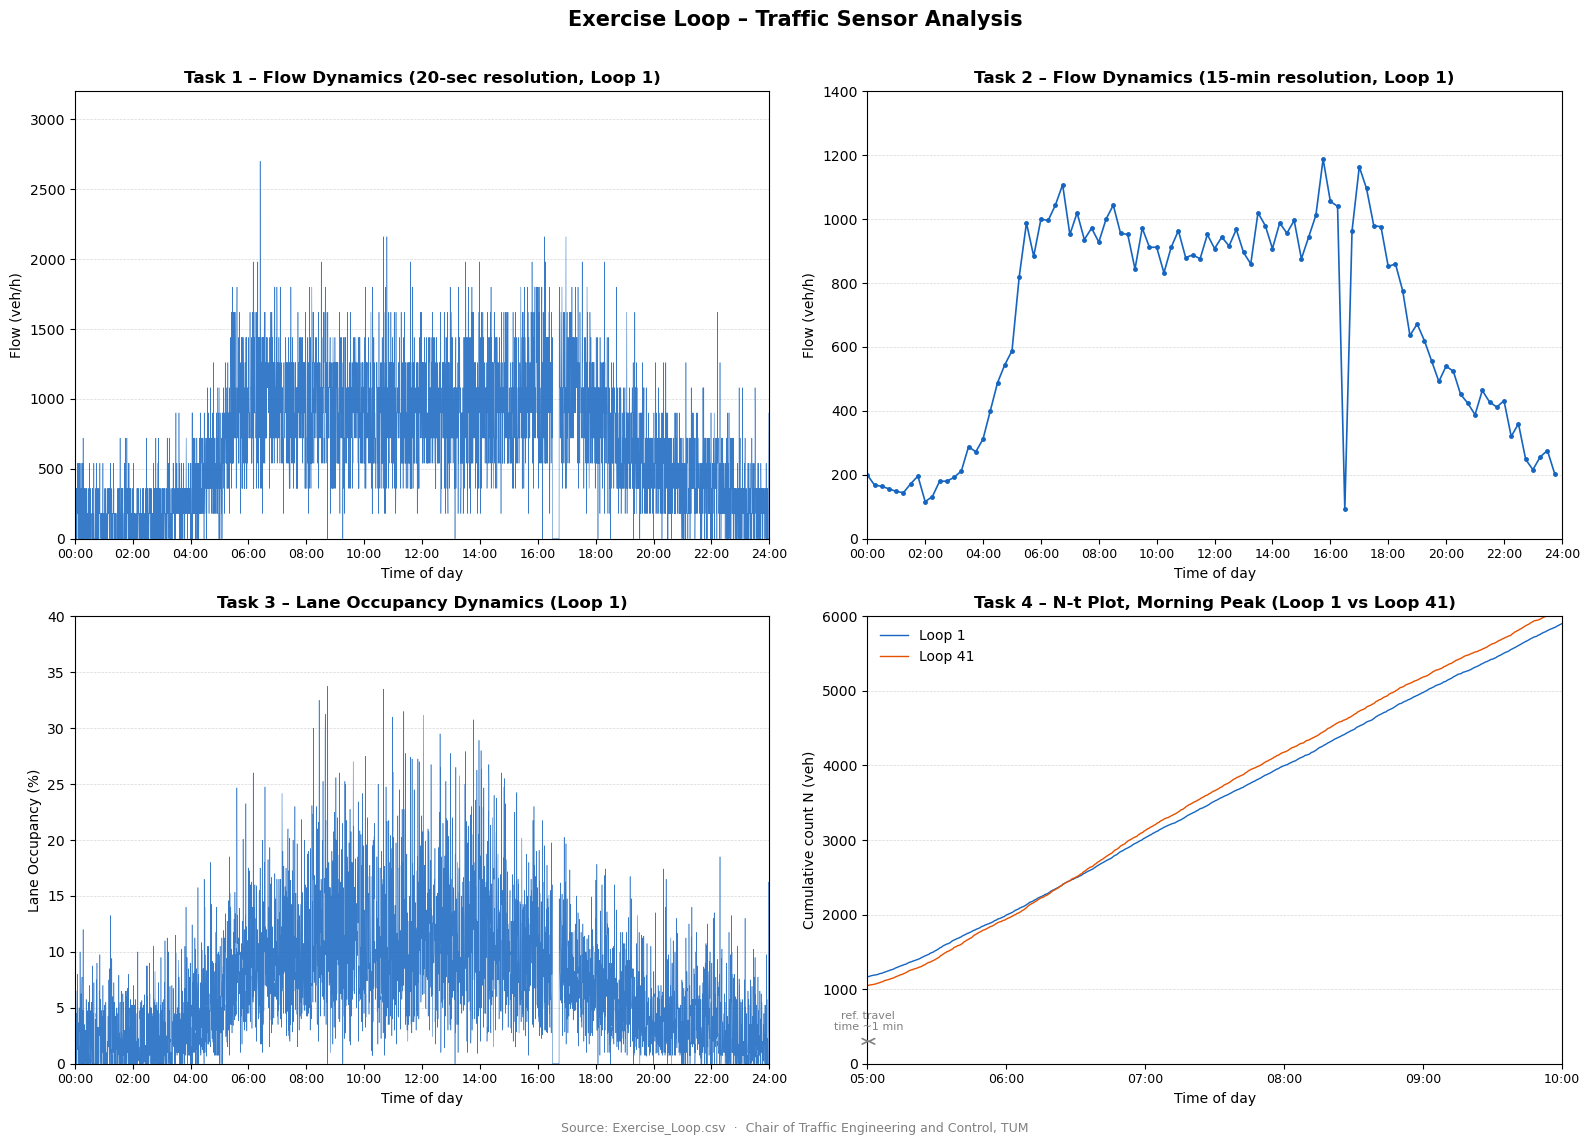

In [3]:
# ============================================================
# Exercise Loop Traffic Data – Solution (Python)
# Matches the 4 tasks from Exercise_Loop_Solution.pdf
#
# Task 1: Flow (veh/h) at 20-sec resolution, Loop 1
# Task 2: Flow (veh/h) at 15-min resolution, Loop 1
# Task 3: Lane occupancy (%) at 20-sec resolution, Loop 1
# Task 4: N-t (cumulative count) plot, Loop 1 vs Loop 41
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ── 1. Load data ──────────────────────────────────────────────
# Update this path to wherever you saved the CSV
file_path = r"C:/Users/ASUS/OneDrive - TUM/Desktop/SOSE 2026/TDCA/Exercise_Loop.csv"

df = pd.read_csv(file_path)

# ── 2. Parse time & compute derived columns ───────────────────
# HHMMSS is stored as an integer like 0, 20, 100, 120 …
# representing HHMMSS with no separator → pad to 6 digits first
df["time_str"]  = df["HHMMSS"].astype(str).str.zfill(6)
df["hour"]      = df["time_str"].str[:2].astype(int)
df["minute"]    = df["time_str"].str[2:4].astype(int)
df["second"]    = df["time_str"].str[4:6].astype(int)
df["time_sec"]  = df["hour"] * 3600 + df["minute"] * 60 + df["second"]
df["time_h"]    = df["time_sec"] / 3600   # fractional hours, for x-axis

# Task 1 & 2: flow = volume / (20 sec ÷ 3600)  →  veh/h
df["flow_20s"]  = df["volume"] / (20 / 3600)

# Task 3: occupancy = 100 × scan_count / 1200
# (60 Hz scanner × 20 sec interval = 1200 possible scans)
df["occupancy"] = 100 * df["scan_count"] / 1200

# ── 3. Filter to Loop 1 (Tasks 1–3) ──────────────────────────
loop1 = df[df["LOOPID"] == 1].copy()

# ── 4. 15-min aggregation for Task 2 ─────────────────────────
loop1["bin_sec"] = (loop1["time_sec"] // 900) * 900
loop1["bin_h"]   = loop1["bin_sec"] / 3600

loop1_15min = (
    loop1.groupby("bin_h", as_index=False)
         .agg(total_volume=("volume", "sum"))
)
# flow = total vehicles in 15 min ÷ (15/60 h)
loop1_15min["agg_flow"] = loop1_15min["total_volume"] / (15 / 60)

# ── 5. Cumulative counts for Task 4 ──────────────────────────
REFERENCE_TRAVEL_TIME_H = 1 / 60   # ≈ 1 minute in hours

loop1_nt = df[df["LOOPID"] == 1].sort_values("time_sec").copy()
loop1_nt["cumulative"] = loop1_nt["volume"].cumsum()
loop1_nt["plot_time_h"] = loop1_nt["time_h"]

loop41_nt = df[df["LOOPID"] == 41].sort_values("time_sec").copy()
loop41_nt["cumulative"] = loop41_nt["volume"].cumsum()
# Shift Loop 41 left by reference travel time for comparison
loop41_nt["plot_time_h"] = loop41_nt["time_h"] - REFERENCE_TRAVEL_TIME_H

# ── 6. Shared formatting helpers ─────────────────────────────
def time_labels(ax, x_min=0, x_max=24, step=2):
    """Set x-axis ticks as HH:00 labels."""
    ticks = np.arange(x_min, x_max + step, step)
    ax.set_xticks(ticks)
    ax.set_xticklabels([f"{int(t):02d}:00" for t in ticks], fontsize=9)
    ax.set_xlim(x_min, x_max)

BLUE   = "#1565C0"
ORANGE = "#E65100"

# ── 7. Build the 2×2 figure ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    "Exercise Loop – Traffic Sensor Analysis",
    fontsize=15, fontweight="bold", y=1.01
)

# ── Task 1: Flow at 20-sec resolution ────────────────────────
ax1 = axes[0, 0]
ax1.plot(loop1["time_h"], loop1["flow_20s"],
         color=BLUE, linewidth=0.4, alpha=0.85)
ax1.set_title("Task 1 – Flow Dynamics (20-sec resolution, Loop 1)",
              fontweight="bold")
ax1.set_ylabel("Flow (veh/h)")
ax1.set_ylim(0, 3200)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(500))
time_labels(ax1)
ax1.set_xlabel("Time of day")
ax1.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# ── Task 2: Flow at 15-min resolution ────────────────────────
ax2 = axes[0, 1]
ax2.plot(loop1_15min["bin_h"], loop1_15min["agg_flow"],
         color=BLUE, linewidth=1.2, marker="o", markersize=2.5)
ax2.set_title("Task 2 – Flow Dynamics (15-min resolution, Loop 1)",
              fontweight="bold")
ax2.set_ylabel("Flow (veh/h)")
ax2.set_ylim(0, 1400)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(200))
time_labels(ax2)
ax2.set_xlabel("Time of day")
ax2.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# ── Task 3: Occupancy dynamics ────────────────────────────────
ax3 = axes[1, 0]
ax3.plot(loop1["time_h"], loop1["occupancy"],
         color=BLUE, linewidth=0.4, alpha=0.85)
ax3.set_title("Task 3 – Lane Occupancy Dynamics (Loop 1)",
              fontweight="bold")
ax3.set_ylabel("Lane Occupancy (%)")
ax3.set_ylim(0, 40)
ax3.yaxis.set_major_locator(ticker.MultipleLocator(5))
time_labels(ax3)
ax3.set_xlabel("Time of day")
ax3.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)

# ── Task 4: N-t plot (morning peak) ──────────────────────────
ax4 = axes[1, 1]
ax4.plot(loop1_nt["plot_time_h"],  loop1_nt["cumulative"],
         color=BLUE,   linewidth=1.0, label="Loop 1")
ax4.plot(loop41_nt["plot_time_h"], loop41_nt["cumulative"],
         color=ORANGE, linewidth=1.0, label="Loop 41")

# Annotate reference travel time arrow
ax4.annotate(
    "", xy=(5 + REFERENCE_TRAVEL_TIME_H, 300), xytext=(5, 300),
    arrowprops=dict(arrowstyle="<->", color="grey", lw=1.2)
)
ax4.text(5 + REFERENCE_TRAVEL_TIME_H / 2, 420,
         "ref. travel\ntime ~1 min",
         ha="center", va="bottom", fontsize=8, color="grey")

ax4.set_title("Task 4 – N-t Plot, Morning Peak (Loop 1 vs Loop 41)",
              fontweight="bold")
ax4.set_ylabel("Cumulative count N (veh)")
ax4.set_ylim(0, 6000)
ax4.yaxis.set_major_locator(ticker.MultipleLocator(1000))
time_labels(ax4, x_min=5, x_max=10, step=1)
ax4.set_xlabel("Time of day")
ax4.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
ax4.legend(loc="upper left", frameon=False)

fig.text(0.5, -0.01,
         "Source: Exercise_Loop.csv  ·  Chair of Traffic Engineering and Control, TUM",
         ha="center", fontsize=9, color="grey")

plt.tight_layout()

# ── 8. Save ───────────────────────────────────────────────────
output_path = r"C:/Users/ASUS/OneDrive - TUM/Desktop/SOSE 2026/TDCA/exercise_loop_solution_plots.png"
plt.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"✓ Saved to: {output_path}")

plt.show()